<a href="https://colab.research.google.com/github/hughman1986/StockResearch/blob/main/Stop_Checking_The_Price%E9%81%B8%E8%82%A1%E5%99%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- WACC 近似：用 yfinance 取到的 beta（缺則 1），利息費用/總債算成本，稅率用實際稅率近似；這對「篩選」很夠用。若你要嚴謹估值，請替換為自己的 CAPM 與債務成本假設。

- 資料缺漏：部分公司報表欄位名稱或歷史期數會缺，程式以 NaN 與備援欄位處理；若個股資料很殘缺，會被自動淘汰。

- 台股：可將 UNIVERSE 換成台股代碼＋.TW，如 "2330.TW"（TSMC）。

- 自動化：若你要把這流程排程跑，或把結果寄成 CSV，我可以幫你再包一層 CLI / airflow 任務。

## 股票池產生器
需要的時候再執行就好, 不然會太久

yfinance有呼叫頻率限制, 不可以跑平行處裡

In [10]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import partial

def normalize_ticker(t: str) -> str:
    # Wikipedia 風格轉 Yahoo 風格（BRK.B -> BRK-B；BF.B -> BF-B）
    t = str(t).strip().upper()
    t = t.replace('.', '-')
    return t


# Step 1 — 取得 S&P 500 成分股
def get_sp500():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    sp500 = pd.read_html(url)[0]
    #sp500_tickers = sp500['Symbol'].tolist()
    sp500_tickers = [normalize_ticker(x) for x in sp500['Symbol'].tolist()]

    return sp500_tickers

# Step 2 — 取得 Russell 2000 成分股
def get_russell2000_from_etf():
    # iShares IWM ETF 持股 CSV（公開可抓）
    etf_url = "https://www.ishares.com/us/products/239710/ishares-russell-2000-etf/1467271812596.ajax?fileType=csv&fileName=IWM_holdings&dataType=fund"
    r = requests.get(etf_url)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), skiprows=9)  # 前幾行是說明文字
    tickers = df['Ticker'].dropna().unique().tolist()
    return tickers

# Step 3 — 合併去重
sp500_list = get_sp500()
print(f"S&P500: {len(sp500_list)} 檔")
r2000_list = get_russell2000_from_etf()
print(f"Russell2000: {len(r2000_list)} 檔")
all_tickers = sorted(set(sp500_list + r2000_list))

print(f"S&P500: {len(sp500_list)} 檔, Russell2000: {len(r2000_list)} 檔, 合併去重後: {len(all_tickers)} 檔")

'''
# 單一 ticker 取市值，重用 session（keep-alive）
def get_market_cap_yf(ticker, session=None):
    try:
        tk = yf.Ticker(ticker, session=None)
        cap = tk.fast_info.get("market_cap", None)
        if cap is None:
            cap = tk.info.get("marketCap", None)
        #print(f"[get_market_cap_yf]{ticker}: {cap}")
        return ticker, cap
    except Exception as exp:
        print(f"[get_market_cap_yf] {exp}")
        return ticker, None

def fetch_market_caps_concurrent(tickers, max_workers=32, chunk_print=500):
    sess = requests.Session()
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(get_market_cap_yf, t, sess) for t in tickers]
        for i, fut in enumerate(as_completed(futures), 1):
            t, cap = fut.result()
            if cap is not None:
                results.append({"Ticker": t, "MarketCap": cap})
            if i % chunk_print == 0:
                print(f"[progress] fetched {i}/{len(tickers)}")
    return pd.DataFrame(results)

df_caps = fetch_market_caps_concurrent(all_tickers, max_workers=5)
print(df_caps.head())
df_caps.to_csv("market_caps.csv", index=False)
print("Saved:", "market_caps.csv")
mid_large_df = (df_caps[df_caps["MarketCap"] >= 2_000_000_000]
                .sort_values("MarketCap", ascending=False).reset_index(drop=True))
'''

# Step 4 — 抓取市值並篩選中大型股
def get_market_cap(ticker):
    try:
        info = yf.Ticker(ticker).fast_info
        return info.get("marketCap", None)
    except Exception:
        return None

results = []
for t in all_tickers:
    cap = get_market_cap(t)
    if cap is not None:
        results.append({"Ticker": t, "MarketCap": cap})
        print(f"{t}: {cap}")

df_caps = pd.DataFrame(results)
print(df_caps.head())
df_caps.to_csv("market_caps.csv", index=False)
print("Saved:", "market_caps.csv")

# 篩選出 Mid Cap (>= 2B) + Large Cap
mid_large_df = df_caps[df_caps["MarketCap"] >= 2_000_000_000].sort_values("MarketCap", ascending=False).reset_index(drop=True)
mid_large_df.to_csv("mid_large_stocks.csv", index=False)
print("Saved:", "mid_large_stocks.csv")

print(f"中大型股數量: {len(mid_large_df)} 檔")
display(mid_large_df.head(20))  # 顯示前 20 檔


HTTPError: HTTP Error 403: Forbidden

In [ ]:
yf.Ticker("AMD").fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

## Step 0 — 安裝與匯入

In [11]:
# 若環境尚未安裝 yfinance
# !pip install yfinance --upgrade

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
pd.options.display.float_format = '{:,.4f}'.format


## Step 1 — 設定股票池與全域參數
可以換成自己的股票清單（支援美股/台股等，台股加 .TW）

In [12]:
# 從 market_caps.csv 讀取股票代號列表
try:
    mid_large_df = pd.read_csv("./drive/MyDrive/StopCheckingThePriceData/market_caps.csv")
    UNIVERSE = mid_large_df["Ticker"].dropna().tolist()
    print(f"從 market_caps.csv 載入 {len(UNIVERSE)} 檔股票。")
except FileNotFoundError:
    print("錯誤：找不到 market_caps.csv 檔案，請先執行股票池產生器。")
    UNIVERSE = [] # 若檔案不存在，設為空列表避免後續錯誤
print(UNIVERSE)

# 估算 WACC 用參數（可依你觀點調整）
RISK_FREE = 0.04            # 近似 10Y 美債 4%（僅作篩選用）
MARKET_PREMIUM = 0.055      # 市場風險溢酬假設 5.5%

# 《Stop Checking The Price》篩選門檻（你可調整）
THRESHOLDS = {
    "roic_min": 0.12,           # ROIC 至少 12%
    "gross_margin_min": 0.30,   # 毛利率至少 30%
    "de_ratio_max": 1.0,        # 負債/權益 <= 1（財務杠杆不過高）
    "fcf_pos_years_min": 2,     # 近 4 年至少有 2 年 FCF 為正
    "rev_cagr_min": 0.05,       # 5 年營收 CAGR 至少 5%
    "roic_gt_wacc": True        # 要求 ROIC > WACC
}

# # 放寬基本面條件:
# THRESHOLDS = {
#     "roic_min": 0.08,           # 原本 12% → 放寬到 8%，中等以上就先納入
#     "gross_margin_min": 0.20,   # 原本 30% → 放寬到 20%，避免只剩軟體/奢侈品
#     "de_ratio_max": 2.0,        # 原本 1 → 放寬到 2，允許稍高槓桿（工業/金融股常見）
#     "fcf_pos_years_min": 1,     # 原本 2 → 放寬到 1，只要近 4 年有 1 年 FCF 為正即可
#     "rev_cagr_min": 0.02,       # 原本 5% → 放寬到 2%，不要強求高成長
#     "roic_gt_wacc": True        # 保留不變，核心條件：ROIC > WACC
# }

從 market_caps.csv 載入 2462 檔股票。
['A', 'AAMI', 'AAOI', 'AAP', 'AAPL', 'AARD', 'AAT', 'ABAT', 'ABBV', 'ABCB', 'ABEO', 'ABG', 'ABM', 'ABNB', 'ABR', 'ABSI', 'ABT', 'ABUS', 'ACA', 'ACAD', 'ACCO', 'ACDC', 'ACEL', 'ACGL', 'ACHR', 'ACIC', 'ACIW', 'ACLS', 'ACLX', 'ACMR', 'ACN', 'ACNB', 'ACNT', 'ACR', 'ACRE', 'ACRS', 'ACT', 'ACTG', 'ACTU', 'ACU', 'ACVA', 'ADBE', 'ADCT', 'ADEA', 'ADI', 'ADM', 'ADMA', 'ADNT', 'ADP', 'ADPT', 'ADSK', 'ADTN', 'ADUS', 'ADV', 'AEBI', 'AEE', 'AEHR', 'AEIS', 'AEO', 'AEP', 'AES', 'AESI', 'AEVA', 'AEYE', 'AFCG', 'AFL', 'AFRI', 'AGIO', 'AGL', 'AGM', 'AGX', 'AGYS', 'AHCO', 'AHH', 'AHR', 'AI', 'AIG', 'AIN', 'AIOT', 'AIP', 'AIR', 'AIRJ', 'AIRS', 'AISP', 'AIV', 'AIZ', 'AJG', 'AKAM', 'AKBA', 'AKR', 'AKRO', 'ALB', 'ALCO', 'ALDX', 'ALE', 'ALEC', 'ALEX', 'ALG', 'ALGN', 'ALGT', 'ALHC', 'ALIT', 'ALKS', 'ALKT', 'ALL', 'ALLE', 'ALLO', 'ALMS', 'ALMU', 'ALNT', 'ALRM', 'ALRS', 'ALT', 'ALTG', 'ALTI', 'ALX', 'AMAL', 'AMAT', 'AMBA', 'AMBC', 'AMBP', 'AMC', 'AMCR', 'AMCX', 'AMD', 'AME', 'AMGN',

## Step 2 — 工具函式：抓財報、對齊欄位與安全取值
yfinance 的年報資料在 .financials/.balance_sheet/.cashflow，欄位為多期（欄為日期）；我們統一取「最近一期」與「近 4 期/5 期」用於趨勢與 CAGR。

In [13]:
def safe_last(df: pd.DataFrame, item: str):
    """從報表 df 安全抓最近一期 item 數值（抓不到則回 NaN）"""
    try:
        return float(df.loc[item].iloc[0])
    except Exception:
        return np.nan

def safe_series(df: pd.DataFrame, item: str, periods=4):
    """取近 periods 期的序列（由新到舊），抓不到回空 Series"""
    try:
        s = df.loc[item].iloc[:periods]
        return pd.to_numeric(s, errors="coerce")
    except Exception:
        return pd.Series(dtype=float)

def get_statements(ticker):
    tk = yf.Ticker(ticker)
    # 年度財報（可能是近幾年，欄為年/期末日）
    inc = tk.financials if tk.financials is not None else pd.DataFrame()
    bs  = tk.balance_sheet if tk.balance_sheet is not None else pd.DataFrame()
    cf  = tk.cashflow if tk.cashflow is not None else pd.DataFrame()
    q_inc = tk.quarterly_financials if tk.quarterly_financials is not None else pd.DataFrame()
    info = {}
    # shares / price / beta（有些欄位可能缺）
    try:
        #price = tk.history(period="1d")["Close"][-1] # 舊版本寫法,
        price = tk.history(period="1d")["Close"].iloc[-1]
    except Exception:
        price = np.nan
    info["price"] = float(price) if pd.notna(price) else np.nan

    # shares outstanding
    try:
        shares = tk.get_shares_full(start=None).iloc[-1]  # 需要較新版本 yfinance
        shares = float(shares)
    except Exception:
        # 後備：fast_info 或 info；有些環境取不到，允許 NaN
        try:
            shares = float(tk.fast_info.get("shares", np.nan))
        except Exception:
            shares = np.nan
    info["shares"] = shares

    # beta
    beta = np.nan
    try:
        beta = float(tk.info.get("beta", np.nan))
    except Exception:
        pass
    # 若沒有 beta，採用 1 作為保守近似
    if not np.isfinite(beta):
        beta = 1.0
    info["beta"] = beta

    return inc, bs, cf, q_inc, info



## Step 3 — 財務指標計算（ROIC、毛利率、FCF、成長、WACC）
這裡給出「可落地」的近似計算：
- NOPAT ≈ Operating Income × (1 − 實際稅率)
- 實際稅率 ≈ Income Tax Expense / Income Before Tax
- 投入資本 ≈ 有息負債（短+長）+ 權益 − 現金等價物
- 毛利率 = Gross Profit / Total Revenue
- FCF = Operating Cash Flow − CapEx
- WACC 近似：
  - Cost of Equity = Rf + β × MRP
  - Cost of Debt ≈ Interest Expense / Total Debt（缺就給 6–8% 假設）
  - 權重用市場值（市值與總債）

In [14]:
# Debug測試用

inc, bs, cf, q_inc, info = get_statements("AAPL")
total_equity = safe_last(bs, "Stockholders Equity") #缺
print("total_equity", total_equity)
lt_debt = safe_last(bs, "Long Term Debt")
print("lt_debt",lt_debt)
st_debt = safe_last(bs, "Current Debt") #缺
print("st_debt",st_debt)
cash = safe_last(bs, "Cash And Cash Equivalents")
print("cash",cash)

# 有些公司會用不同命名；增加一點容錯
if np.isnan(cash):
    cash = safe_last(bs, "Cash")
total_debt = np.nansum([lt_debt, st_debt])
print("total_debt",total_debt)

de_ratio = np.nan
if np.isfinite(total_debt) and np.isfinite(total_equity) and total_equity != 0:
    de_ratio = total_debt / total_equity
print("de_ratio" , de_ratio)


total_equity 56950000000.0
lt_debt 85750000000.0
st_debt 20879000000.0
cash 29943000000.0
total_debt 106629000000.0
de_ratio 1.872326602282704


In [15]:
def compute_metrics(inc, bs, cf, info, lookback_years_for_cagr=5):
    # 近期欄位
    revenue = safe_last(inc, "Total Revenue")
    gross_profit = safe_last(inc, "Gross Profit")
    operating_income = safe_last(inc, "Operating Income")
    income_before_tax = safe_last(inc, "Income Before Tax")
    income_tax = safe_last(inc, "Income Tax Expense")
    net_income = safe_last(inc, "Net Income")

    # 資產負債表
    # total_equity = safe_last(bs, "Total Stockholder Equity")
    total_equity = safe_last(bs, "Stockholders Equity")

    lt_debt = safe_last(bs, "Long Term Debt")
    # st_debt = safe_last(bs, "Short Long Term Debt")
    st_debt = safe_last(bs, "Current Debt")

    cash = safe_last(bs, "Cash And Cash Equivalents")
    # 有些公司會用不同命名；增加一點容錯
    if np.isnan(cash):
        cash = safe_last(bs, "Cash")
    total_debt = np.nansum([lt_debt, st_debt])

    # 稅率（實際）
    tax_rate = np.nan
    if np.isfinite(income_before_tax) and income_before_tax != 0:
        tax_rate = max(0.0, min(0.35, income_tax / income_before_tax))  # clip 到合理區間
    if not np.isfinite(tax_rate):
        tax_rate = 0.21  # fallback

    # NOPAT
    nopat = np.nan
    if np.isfinite(operating_income):
        nopat = operating_income * (1 - tax_rate)

    # 投入資本（保守近似）
    invested_capital = np.nan
    if np.isfinite(total_equity) or np.isfinite(total_debt):
        invested_capital = (np.nan_to_num(total_debt) + np.nan_to_num(total_equity)) - np.nan_to_num(cash)
        invested_capital = invested_capital if invested_capital > 0 else np.nan

    # ROIC
    roic = np.nan
    if np.isfinite(nopat) and np.isfinite(invested_capital) and invested_capital != 0:
        roic = nopat / invested_capital

    # 毛利率
    gross_margin = np.nan
    if np.isfinite(gross_profit) and np.isfinite(revenue) and revenue != 0:
        gross_margin = gross_profit / revenue

    # FCF（近 4 年/期）
    ocf_series = safe_series(cf, "Operating Cash Flow", periods=4)
    capex_series = -safe_series(cf, "Capital Expenditure", periods=4)  # yfinance 多為負數，取負還原投入額
    fcf_series = pd.Series(dtype=float)
    if len(ocf_series) and len(capex_series):
        fcf_series = ocf_series - capex_series
    fcf_pos_years = int((fcf_series > 0).sum()) if len(fcf_series) else 0

    # 營收 CAGR（近 5 年）
    rev_series = safe_series(inc, "Total Revenue", periods=lookback_years_for_cagr)
    rev_cagr = np.nan
    if len(rev_series) >= 2 and rev_series.iloc[-1] > 0 and rev_series.iloc[0] > 0:
        n = len(rev_series) - 1
        rev_cagr = (rev_series.iloc[0] / rev_series.iloc[-1])**(1/n) - 1  # 注意 yfinance 欄順序通常新->舊
        # 如果序列方向與預期相反，修正
        if not np.isfinite(rev_cagr):
            rev_cagr = np.nan
        else:
            rev_cagr = -rev_cagr  # 調整方向：讓「新/舊」變成「舊->新」的 CAGR
    # 若上面方向判斷不穩，你也可改成：rev_series[::-1] 再計算

    # 估算 WACC
    # 市值
    market_cap = np.nan
    if np.isfinite(info.get("price", np.nan)) and np.isfinite(info.get("shares", np.nan)):
        market_cap = info["price"] * info["shares"]
    beta = info.get("beta", 1.0)

    cost_equity = RISK_FREE + beta * MARKET_PREMIUM
    # 負債成本：利息支出 / 總債（近似；抓不到就 7% 假設）
    interest_expense = safe_last(inc, "Interest Expense")
    if not np.isfinite(interest_expense):
        interest_expense = safe_last(cf, "Interest Paid")  # 次佳
        interest_expense = abs(interest_expense) if np.isfinite(interest_expense) else np.nan
    if np.isfinite(total_debt) and total_debt > 0 and np.isfinite(interest_expense):
        cost_debt = min(0.12, max(0.01, interest_expense / total_debt))
    else:
        cost_debt = 0.07  # 假設值

    # 權重
    E = market_cap if np.isfinite(market_cap) else 0.0
    D = total_debt if np.isfinite(total_debt) else 0.0
    V = E + D if (E + D) > 0 else np.nan

    wacc = np.nan
    if np.isfinite(V):
        wacc = (E/V) * cost_equity + (D/V) * cost_debt * (1 - tax_rate)

    # 槓桿（Debt/Equity）
    de_ratio = np.nan
    if np.isfinite(total_debt) and np.isfinite(total_equity) and total_equity != 0:
        de_ratio = total_debt / total_equity

    return {
        "Revenue": revenue,
        "GrossProfit": gross_profit,
        "OperatingIncome": operating_income,
        "IncomeBeforeTax": income_before_tax,
        "IncomeTax": income_tax,
        "NetIncome": net_income,
        "TotalDebt": total_debt,
        "TotalEquity": total_equity,
        "Cash": cash,
        "InvestedCapital": invested_capital,
        "NOPAT": nopat,
        "ROIC": roic,
        "GrossMargin": gross_margin,
        "FCF_Positive_Years_Last4": fcf_pos_years,
        "Rev_CAGR_5y_est": rev_cagr,
        "WACC_est": wacc,
        "Debt_to_Equity": de_ratio,
        "Price": info.get("price", np.nan),
        "MarketCap": market_cap,
        "Beta": beta
    }


## Step 4 — 《Stop Checking The Price》篩選規則實作
重點：ROIC 高且穩定、毛利率穩定/高、財務穩健、成長性，以及（可選）ROIC > WACC

In [16]:
def pass_filters(row, th=THRESHOLDS):
    conds = []
    # 1) ROIC
    conds.append(pd.notna(row["ROIC"]) and row["ROIC"] >= th["roic_min"])
    # 2) 毛利率
    conds.append(pd.notna(row["GrossMargin"]) and row["GrossMargin"] >= th["gross_margin_min"])
    # 3) 財務穩健：槓桿、FCF 年數
    conds.append(pd.notna(row["Debt_to_Equity"]) and row["Debt_to_Equity"] <= th["de_ratio_max"])
    conds.append(pd.notna(row["FCF_Positive_Years_Last4"]) and row["FCF_Positive_Years_Last4"] >= th["fcf_pos_years_min"])
    # 4) 成長性：營收 CAGR
    conds.append(pd.notna(row["Rev_CAGR_5y_est"]) and row["Rev_CAGR_5y_est"] >= th["rev_cagr_min"])
    # 5) ROIC > WACC（可開關）
    if th.get("roic_gt_wacc", False):
        conds.append(pd.notna(row["WACC_est"]) and pd.notna(row["ROIC"]) and row["ROIC"] > row["WACC_est"])
    return all(conds)


## Step 5 — 跑整個股票池並輸出結果

In [ ]:
from tqdm.notebook import tqdm

records = []
total_tickers = len(UNIVERSE)
print(f"開始處理 {total_tickers} 檔股票...")

for i, t in  enumerate(tqdm(UNIVERSE, unit="檔") ):
    try:
        inc, bs, cf, q_inc, info = get_statements(t)
        met = compute_metrics(inc, bs, cf, info)
        met["Ticker"] = t
        records.append(met)

    except Exception as e:
        print(f"[WARN] {t}: {e}")

df = pd.DataFrame(records)
cols_order = ["Ticker", "Price", "MarketCap", "ROIC", "WACC_est", "GrossMargin",
              "Rev_CAGR_5y_est", "Debt_to_Equity", "FCF_Positive_Years_Last4",
              "InvestedCapital", "NOPAT", "TotalDebt", "TotalEquity", "Cash",
              "Revenue", "GrossProfit", "OperatingIncome", "Beta"]
df = df[cols_order]

# 篩選
df["PASS"] = df.apply(pass_filters, axis=1)
df_pass = df[df["PASS"]].sort_values(["ROIC", "GrossMargin"], ascending=False).reset_index(drop=True)

display(df.style.background_gradient(subset=["ROIC","GrossMargin","Rev_CAGR_5y_est"], cmap="Greens"))
print("\n===== 通過篩選（PASS=True）=====")
display(df_pass)

開始處理 2462 檔股票...


  0%|          | 0/2462 [00:00<?, ?檔/s]

ERROR:yfinance:$ARIS: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$AVDX: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$BASE: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$BHLB: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$BLDE: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$BRKL: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$BYON: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$CFFI: possibly delisted; no price data found  (period=1d)
ERROR:yfinance:$CRGX: possibly delisted; no price data found  (period=1d)


Step 5 — 跑整個股票池並輸出結果(平行處裡版本, 但yfinance不能高頻呼叫, 所以這段無用)

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_ticker(t):
    """Helper function to process a single ticker and return its metrics."""
    try:
        inc, bs, cf, q_inc, info = get_statements(t)
        met = compute_metrics(inc, bs, cf, info)
        met["Ticker"] = t
        return met
    except Exception as e:
        # print(f"[WARN] {t}: {e}") # Suppress excessive error messages during parallel processing
        return {"Ticker": t, "Error": str(e)} # Return error info

records = []
total_tickers = len(UNIVERSE)
print(f"開始處理 {total_tickers} 檔股票...")

# Use ThreadPoolExecutor for parallel processing
# Adjust max_workers based on your environment and yfinance limits
max_workers = 10 # Reduced from 32 due to yfinance limits mentioned earlier
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    # Submit tasks to the executor
    future_to_ticker = {executor.submit(process_ticker, t): t for t in UNIVERSE}

    for i, future in enumerate(as_completed(future_to_ticker), 1):
        ticker = future_to_ticker[future]
        try:
            met = future.result()
            if "Error" not in met:
                records.append(met)
            else:
                # Optionally print error for failed tickers
                # print(f"[WARN] {ticker}: {met['Error']}")
                pass # Suppress error printing by default in parallel mode
        except Exception as exc:
            print(f"[WARN] {ticker} generated an exception during result retrieval: {exc}")


        # Print progress
        if i % 10 == 0 or i == total_tickers:
            print(f"已處理 {i}/{total_tickers} 檔 ({((i)/total_tickers):.1%})")


df = pd.DataFrame(records)
cols_order = ["Ticker", "Price", "MarketCap", "ROIC", "WACC_est", "GrossMargin",
              "Rev_CAGR_5y_est", "Debt_to_Equity", "FCF_Positive_Years_Last4",
              "InvestedCapital", "NOPAT", "TotalDebt", "TotalEquity", "Cash",
              "Revenue", "GrossProfit", "OperatingIncome", "Beta"]

# Ensure all columns exist before reindexing
existing_cols = [col for col in cols_order if col in df.columns]
df = df[existing_cols]


# 篩選
df["PASS"] = df.apply(pass_filters, axis=1)
df_pass = df[df["PASS"]].sort_values(["ROIC", "GrossMargin"], ascending=False).reset_index(drop=True)

display(df.style.background_gradient(subset=["ROIC","GrossMargin","Rev_CAGR_5y_est"], cmap="Greens"))
print("\n===== 通過篩選（PASS=True）=====")
display(df_pass)

## Step 6 — 匯出結果（選擇性）

In [9]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
df.to_csv(f"./drive/MyDrive/StopCheckingThePriceData/scp_screen_all_{timestamp}.csv", index=False)
df_pass.to_csv(f"./drive/MyDrive/StopCheckingThePriceData/scp_screen_pass_{timestamp}.csv", index=False)
print("Saved:", f"scp_screen_all_{timestamp}.csv", "and", f"scp_screen_pass_{timestamp}.csv")


Saved: scp_screen_all_20251020_1634.csv and scp_screen_pass_20251020_1634.csv


## Step 7 — 出場條件（警示器）
書的精神：看基本面惡化而非股價波動。這裡做一個「兩年趨勢」的簡易判斷：
- ROIC 連續下滑且跌破 WACC
- 毛利率明顯走弱（與近年均值比下滑）
- FCF 連續轉負或負債快速升高

In [ ]:
# === Step 7 (robust version) — 出場條件（警示器） ===

def exit_flags(ticker, roic_series, gm_series, fcf_series, wacc_est, debt_series=None, equity_series=None):
    """
    roic_series / gm_series / fcf_series：由新到舊（近 4 期）的數列
    """
    flags = []
    # 1) ROIC 下滑 + 跌破 WACC
    if len(roic_series) >= 3 and roic_series.notna().sum() >= 3:
        down_trend = (roic_series.iloc[0] < roic_series.iloc[1] < roic_series.iloc[2])
        if down_trend and pd.notna(wacc_est) and pd.notna(roic_series.iloc[0]) and roic_series.iloc[0] < wacc_est:
            flags.append("ROIC downtrend & < WACC")

    # 2) 毛利率走弱（低於近年均值的 85%）
    if len(gm_series) >= 4 and gm_series.notna().sum() >= 2:
        gm_mean = gm_series.mean(skipna=True)
        if pd.notna(gm_series.iloc[0]) and pd.notna(gm_mean) and gm_mean != 0 and gm_series.iloc[0] < 0.85 * gm_mean:
            flags.append("Gross margin weakening")

    # 3) FCF 連續兩期為負
    if len(fcf_series) >= 2 and fcf_series.notna().sum() >= 2:
        if (fcf_series.iloc[0] < 0) and (fcf_series.iloc[1] < 0):
            flags.append("FCF negative 2 periods")

    # 4) 槓桿快速升高（Debt/Equity）
    if debt_series is not None and equity_series is not None:
        if len(debt_series) >= 2 and len(equity_series) >= 2:
            de0 = (debt_series.iloc[0] / equity_series.iloc[0]) if pd.notna(debt_series.iloc[0]) and pd.notna(equity_series.iloc[0]) and equity_series.iloc[0] != 0 else np.nan
            de1 = (debt_series.iloc[1] / equity_series.iloc[1]) if pd.notna(debt_series.iloc[1]) and pd.notna(equity_series.iloc[1]) and equity_series.iloc[1] != 0 else np.nan
            if np.isfinite(de0) and np.isfinite(de1) and de0 > 1.5 * de1:
                flags.append("Leverage rising fast")

    return flags

def get_exit_checks(ticker):
    inc, bs, cf, q_inc, info = get_statements(ticker)

    # 取近 4 年/期序列（新到舊）
    roic_list, gm_list, fcf_list = [], [], []
    debt_list, eq_list = [], []

    # 嘗試每期用 compute_metrics 估算該期 ROIC / GrossMargin
    n_cols = inc.shape[1] if isinstance(inc, pd.DataFrame) else 0
    n_cols = min(n_cols, 4)  # 最多 4 期
    for i in range(n_cols):
        try:
            sub_inc = inc.iloc[:, i:i+1] if n_cols > 0 else pd.DataFrame()
            sub_bs  = bs.iloc[:, i:i+1]  if isinstance(bs, pd.DataFrame) and bs.shape[1] > i else pd.DataFrame()
            sub_cf  = cf.iloc[:, i:i+1]  if isinstance(cf, pd.DataFrame) and cf.shape[1] > i else pd.DataFrame()

            met_i = compute_metrics(sub_inc, sub_bs, sub_cf, info)
            roic_list.append(met_i.get("ROIC", np.nan))
            gm_list.append(met_i.get("GrossMargin", np.nan))

            ocf = safe_last(sub_cf, "Operating Cash Flow")
            capex = -safe_last(sub_cf, "Capital Expenditure")
            fcf_list.append(ocf - capex if np.isfinite(ocf) and np.isfinite(capex) else np.nan)

            debt_list.append(met_i.get("TotalDebt", np.nan))
            eq_list.append(met_i.get("TotalEquity", np.nan))
        except Exception:
            roic_list.append(np.nan)
            gm_list.append(np.nan)
            fcf_list.append(np.nan)
            debt_list.append(np.nan)
            eq_list.append(np.nan)

    roic_s = pd.Series(roic_list, dtype=float)
    gm_s   = pd.Series(gm_list, dtype=float)
    fcf_s  = pd.Series(fcf_list, dtype=float)
    debt_s = pd.Series(debt_list, dtype=float)
    eq_s   = pd.Series(eq_list, dtype=float)

    met_latest = compute_metrics(inc, bs, cf, info)
    flags = exit_flags(ticker, roic_s, gm_s, fcf_s, met_latest.get("WACC_est", np.nan), debt_s, eq_s)

    return met_latest, flags

# === 執行出場檢查 ===
if 'df_pass' not in globals():
    raise RuntimeError("請先執行前面步驟，建立 df_pass 與 df")

# 若沒有任何通過名單，改用整體 df（或你自訂的候選清單）
if df_pass.empty:
    print("[INFO] 沒有股票通過篩選，改對整體 df 做出場警示（你也可以改成只挑前 N 檔）。")
    tickers_to_check = df["Ticker"].dropna().tolist()
else:
    tickers_to_check = df_pass["Ticker"].dropna().tolist()

print(f"[DEBUG] 將檢查 {len(tickers_to_check)} 檔：", tickers_to_check[:10], "..." if len(tickers_to_check) > 10 else "")

exit_rows = []
for t in tickers_to_check:
    try:
        met, flags = get_exit_checks(t)
        exit_rows.append({
            "Ticker": t,
            "Price": met.get("Price", np.nan),
            "ROIC": met.get("ROIC", np.nan),
            "WACC_est": met.get("WACC_est", np.nan),
            "GrossMargin": met.get("GrossMargin", np.nan),
            "ExitFlags": ", ".join(flags) if flags else ""
        })
    except Exception as e:
        print(f"[WARN] Exit check failed for {t}: {e}")

exit_df = pd.DataFrame(exit_rows)

# 安全排序：只有在欄位存在且非全空時才排序
if not exit_df.empty and ("ROIC" in exit_df.columns) and exit_df["ROIC"].notna().any():
    exit_df = exit_df.sort_values("ROIC", ascending=False).reset_index(drop=True)
else:
    print("[INFO] exit_df 為空或缺 ROIC 欄位，略過排序。")

display(exit_df)


[INFO] 沒有股票通過篩選，改對整體 df 做出場警示（你也可以改成只挑前 N 檔）。
[DEBUG] 將檢查 1024 檔： ['NVDA', 'MSFT', 'AAPL', 'GOOGL', 'GOOG', 'AMZN', 'META', 'AVGO', 'TSLA', 'BRK-B'] ...


Exception ignored from cffi callback <function buffer_callback at 0x7c01e8bb1940>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/curl_cffi/curl.py", line 100, in buffer_callback
    @ffi.def_extern()
    
KeyboardInterrupt: 
Exception ignored from cffi callback <function buffer_callback at 0x7c01e8bb1940>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/curl_cffi/curl.py", line 100, in buffer_callback
    @ffi.def_extern()
    
KeyboardInterrupt: 
ERROR:yfinance:$DHR: possibly delisted; no price data found  (period=1d)
Exception ignored from cffi callback <function buffer_callback at 0x7c01e8bb1940>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/curl_cffi/curl.py", line 100, in buffer_callback
    @ffi.def_extern()
    
KeyboardInterrupt: 
Exception ignored from cffi callback <function buffer_callback at 0x7c01e8bb1940>:
Traceback (most recent call last):
  File "/usr/local/lib/

,Ticker,Price,ROIC,WACC_est,GrossMargin,ExitFlags
0,JKHY,160.3900,17.8034,0.0807,0.4135,
1,DFH,28.0000,16.5467,0.1353,0.1861,
2,ALG,222.2800,15.8798,0.0993,0.2533,
3,MSFT,520.1700,10.2459,0.0975,0.6882,
4,SMCI,45.3700,9.3745,0.1132,0.1375,
...,...,...,...,...,...,...
1019,EFSC,56.9000,NaN,0.0903,NaN,
1020,TARS,54.2100,NaN,0.0836,0.9299,FCF negative 2 periods
1021,IRON,59.8600,NaN,0.1754,NaN,FCF negative 2 periods
1022,NSP,51.1200,NaN,0.0655,0.1599,


## Step 8 — 視覺化（選擇性）：ROIC vs. 毛利率



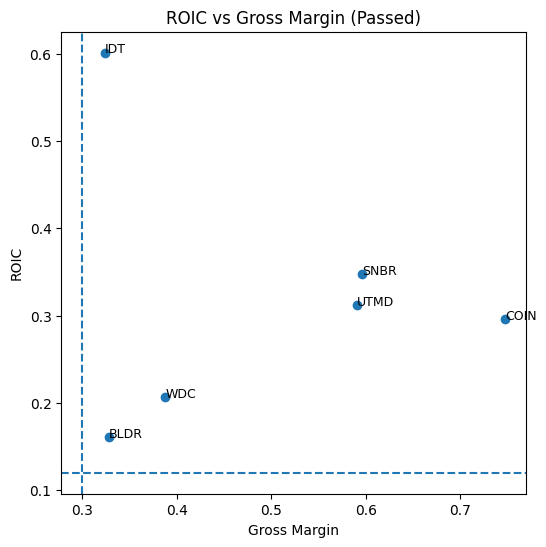

In [ ]:
import matplotlib.pyplot as plt

plot_df = df_pass.dropna(subset=["ROIC","GrossMargin"])
plt.figure(figsize=(6,6))
plt.scatter(plot_df["GrossMargin"], plot_df["ROIC"])
for _, r in plot_df.iterrows():
    plt.text(r["GrossMargin"], r["ROIC"], r["Ticker"], fontsize=9)
plt.axhline(THRESHOLDS["roic_min"], linestyle="--")
plt.axvline(THRESHOLDS["gross_margin_min"], linestyle="--")
plt.xlabel("Gross Margin")
plt.ylabel("ROIC")
plt.title("ROIC vs Gross Margin (Passed)")
plt.show()
